# Gunshot Classification - Final Model

This notebook presents a production-ready gunshot classification pipeline using MFCC features and a CNN model.
The dataset contains gunshot recordings from 9 folders, merged into 8 final classes by combining M16 and M4 into a single M-Family class.
The workflow includes robust preprocessing, feature extraction, class-balanced training with weighted loss, and final evaluation on held-out validation and test sets.

In [ ]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset

import torchaudio
import torchaudio.transforms as T

from sklearn.metrics import classification_report, confusion_matri

import torch.nn.functional as F


In [2]:
print('=' * 50)
print('SECTION 1: SETUP')
print('=' * 50)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SECTION 1: SETUP
Using device: cpu


## Section 2 - Dataset and Class Mapping

The dataset has 9 folder names but 8 target classes for training.
M16 and M4 are acoustically similar platform variants, so they are merged into one label called **M-Family** to reduce label overlap and improve class consistency.

In [3]:
print('=' * 50)
print('SECTION 2: CLASS MAPPING')
print('=' * 50)

class_to_idx = {
    'AK-12': 0,
    'AK-47': 1,
    'IMI Desert Eagle': 2,
    'M16': 3,
    'M4': 3,
    'M249': 4,
    'MG-42': 5,
    'MP5': 6,
    'Zastava M92': 7
}

idx_to_class = {
    0: 'AK-12',
    1: 'AK-47',
    2: 'IMI Desert Eagle',
    3: 'M-Family',
    4: 'M249',
    5: 'MG-42',
    6: 'MP5',
    7: 'Zastava M92'
}

print(f'Final number of classes: {len(idx_to_class)}')

SECTION 2: CLASS MAPPING
Final number of classes: 8


In [4]:
print('=' * 50)
print('SECTION 2: DATASET SCAN')
print('=' * 50)

dataset_path = Path('gunshot-audio-dataset')
raw_class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

for class_name in raw_class_names:
    file_count = len(list((dataset_path / class_name).glob('*.wav')))
    print(f'{class_name}: {file_count} files')

SECTION 2: DATASET SCAN
AK-12: 98 files
AK-47: 72 files
IMI Desert Eagle: 100 files
M16: 100 files
M249: 99 files
M4: 100 files
MG-42: 100 files
MP5: 100 files
Zastava M92: 82 files


## Section 3 - Audio Preprocessing

The preprocessing pipeline standardizes all audio clips so the model sees consistent inputs.
Mono conversion removes channel mismatch, resampling aligns sample rate, duration standardization fixes temporal size, normalization stabilizes amplitude scale, and pre-emphasis boosts high-frequency transients that are useful in gunshot signatures.

In [5]:
def convert_to_mono(waveform: torch.Tensor) -> torch.Tensor:
    if waveform.shape[0] > 1:
        return waveform.mean(dim=0, keepdim=True)
    return waveform

In [6]:
def resample(waveform: torch.Tensor, orig_sr: int, target_sr: int) -> torch.Tensor:
    if orig_sr != target_sr:
        return T.Resample(orig_sr, target_sr)(waveform)
    return waveform

In [7]:
def standardize_duration(waveform: torch.Tensor, target_length: int) -> torch.Tensor:
    current_length = waveform.shape[1]
    if current_length < target_length:
        return torch.nn.functional.pad(waveform, (0, target_length - current_length))
    if current_length > target_length:
        return waveform[:, :target_length]
    return waveform

In [8]:
def normalize(waveform: torch.Tensor) -> torch.Tensor:
    return waveform / (waveform.abs().max() + 1e-8)

In [9]:
def pre_emphasis(waveform: torch.Tensor, coef: float = 0.97) -> torch.Tensor:
    emphasized = torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)
    return emphasized

In [10]:
TARGET_SR = 48_000
TARGET_DURATION = 2.0
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def preprocessing_pipeline(file_path: Path) -> tuple[torch.Tensor, int]:
    try:
        waveform, sample_rate = torchaudio.load(file_path, backend='sox_io')
    except:
        # Fallback to soundfile if sox_io is not available
        import soundfile as sf
        waveform_np, sample_rate = sf.read(file_path)
        waveform = torch.from_numpy(waveform_np).float()
        if waveform.dim() == 1:
            waveform = waveform.unsqueeze(0)
    waveform = convert_to_mono(waveform)
    waveform = resample(waveform, sample_rate, TARGET_SR)
    waveform = standardize_duration(waveform, TARGET_LENGTH)
    waveform = normalize(waveform)
    waveform = pre_emphasis(waveform)
    return waveform, TARGET_SR

## Section 4 - Feature Extraction

MFCCs summarize short-time spectral envelope patterns and are highly effective for audio event classification.
They provide a compact time-frequency representation that works well with CNNs for discriminative acoustic signatures like different weapon shots.

In [11]:
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 64

mfcc_transform = T.MFCC(
    sample_rate=TARGET_SR,
    n_mfcc=N_MFCC,
    melkwargs={
        'n_fft': N_FFT,
        'hop_length': HOP_LENGTH,
        'n_mels': N_MELS
    }
)

In [12]:
print('=' * 50)
print('SECTION 4: FEATURE EXTRACTION')
print('=' * 50)

features_root = Path('features')
features_root.mkdir(exist_ok=True)

for class_name in raw_class_names:
    source_dir = dataset_path / class_name
    target_dir = features_root / class_name
    target_dir.mkdir(parents=True, exist_ok=True)

    audio_files = sorted(source_dir.glob('*.wav'))
    for audio_path in audio_files:
        waveform, _ = preprocessing_pipeline(audio_path)
        mfcc = mfcc_transform(waveform)
        out_path = target_dir / f'{audio_path.stem}.pt'
        torch.save(mfcc, out_path)

    print(f'{class_name}: extracted {len(audio_files)} feature tensors')

SECTION 4: FEATURE EXTRACTION
AK-12: extracted 98 feature tensors
AK-47: extracted 72 feature tensors
IMI Desert Eagle: extracted 100 feature tensors
M16: extracted 100 feature tensors
M249: extracted 99 feature tensors
M4: extracted 100 feature tensors
MG-42: extracted 100 feature tensors
MP5: extracted 100 feature tensors
Zastava M92: extracted 82 feature tensors


In [13]:
print('=' * 50)
print('SECTION 4: FEATURE VERIFICATION')
print('=' * 50)

total_features = 0
sample_shape = None

for class_name in raw_class_names:
    class_count = len(list((features_root / class_name).glob('*.pt')))
    total_features += class_count
    print(f'{class_name}: {class_count} feature files')

if raw_class_names:
    first_feature = sorted((features_root / raw_class_names[0]).glob('*.pt'))[0]
    sample_shape = torch.load(first_feature).shape

print(f'Total feature files: {total_features}')
print(f'Sample MFCC tensor shape: {sample_shape}')

SECTION 4: FEATURE VERIFICATION
AK-12: 98 feature files
AK-47: 72 feature files
IMI Desert Eagle: 100 feature files
M16: 100 feature files
M249: 99 feature files
M4: 100 feature files
MG-42: 100 feature files
MP5: 100 feature files
Zastava M92: 82 feature files
Total feature files: 851
Sample MFCC tensor shape: torch.Size([1, 40, 188])


## Section 5 - Dataset and DataLoaders

We use a 70/15/15 split for train/validation/test to preserve unbiased model selection and final evaluation.
Training data uses light feature-space augmentation (noise and time shift) to improve robustness without changing class semantics.

In [14]:
class GunshotDataset(Dataset):
    def __init__(self, features_path: Path, class_to_idx_map: dict[str, int], augment: bool = False):
        self.features_path = Path(features_path)
        self.class_to_idx_map = class_to_idx_map
        self.augment = augment
        self.samples: list[tuple[Path, int]] = []

        for class_name in sorted(class_to_idx_map.keys()):
            class_dir = self.features_path / class_name
            if not class_dir.exists():
                continue
            for feature_file in sorted(class_dir.glob('*.pt')):
                self.samples.append((feature_file, class_to_idx_map[class_name]))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        feature_file, label = self.samples[index]
        features = torch.load(feature_file).float()

        if self.augment:
            if torch.rand(1).item() > 0.6:
                features = features + torch.randn_like(features) * 0.01
            if torch.rand(1).item() > 0.6:
                shift = torch.randint(-10, 11, (1,)).item()
                features = torch.roll(features, shifts=shift, dims=-1)

        return features, label

In [15]:
print('=' * 50)
print('SECTION 5: DATASET & DATALOADERS')
print('=' * 50)

from torch.utils.data import Dataset, DataLoader, random_split
import random

class GunshotDataset(Dataset):
    def __init__(self, features_dir, class_to_idx, augment=False):
        self.samples = []
        self.augment = augment
        features_root = Path(features_dir)

        for cls_dir in features_root.iterdir():
            if cls_dir.is_dir() and cls_dir.name in class_to_idx:
                label = class_to_idx[cls_dir.name]
                for pt_file in sorted(cls_dir.glob('*.pt')):
                    self.samples.append((pt_file, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        mfcc = torch.load(path, weights_only=True)

        if self.augment:
            # Random time shift
            shift = random.randint(-10, 10)
            mfcc = torch.roll(mfcc, shift, dims=2)
            # Random noise
            mfcc = mfcc + torch.randn_like(mfcc) * 0.01

        return mfcc, label

# Dataset split — 70/15/15
torch.manual_seed(42)
full_dataset = GunshotDataset('features', class_to_idx, augment=False)
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(total), [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = GunshotDataset('features', class_to_idx, augment=True)
train_dataset.samples = [full_dataset.samples[i] for i in train_indices.indices]

val_dataset = GunshotDataset('features', class_to_idx, augment=False)
val_dataset.samples = [full_dataset.samples[i] for i in val_indices.indices]

test_dataset = GunshotDataset('features', class_to_idx, augment=False)
test_dataset.samples = [full_dataset.samples[i] for i in test_indices.indices]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print(f'Total samples  : {total}')
print(f'Train samples  : {len(train_dataset)}')
print(f'Val samples    : {len(val_dataset)}')
print(f'Test samples   : {len(test_dataset)}')

# Class weights for weighted loss
from collections import Counter
import numpy as np

train_labels = [label for _, label in train_dataset.samples]
counts = Counter(train_labels)
total_train = len(train_labels)
class_weights = torch.tensor(
    [total_train / (8 * counts.get(i, 1)) for i in range(8)],
    dtype=torch.float32
).to(device)

print(f'Class weights: {class_weights.tolist()}')

SECTION 5: DATASET & DATALOADERS
Total samples  : 851
Train samples  : 595
Val samples    : 127
Test samples   : 129
Class weights: [1.3048245906829834, 1.5178571939468384, 1.0475351810455322, 0.5237675905227661, 1.0625, 1.0475351810455322, 1.0625, 1.1442307233810425]


In [16]:
print('=' * 50)
print('SECTION 5: CLASS DISTRIBUTION AND WEIGHTS')
print('=' * 50)

num_classes = len(idx_to_class)
train_class_counts = torch.zeros(num_classes, dtype=torch.float32)

for _, label in train_dataset:
    train_class_counts[label] += 1

for idx in range(num_classes):
    class_name = idx_to_class[idx]
    print(f'{class_name}: {int(train_class_counts[idx].item())} train samples')

class_weights = 1.0 / train_class_counts.clamp(min=1.0)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

print(f'Class weights: {class_weights.cpu().numpy().round(4)}')

SECTION 5: CLASS DISTRIBUTION AND WEIGHTS
AK-12: 57 train samples
AK-47: 49 train samples
IMI Desert Eagle: 71 train samples
M-Family: 142 train samples
M249: 70 train samples
MG-42: 71 train samples
MP5: 70 train samples
Zastava M92: 65 train samples
Class weights: [0.1498 0.1743 0.1203 0.0601 0.122  0.1203 0.122  0.1314]


## Section 6 - Model Architecture

The CNN uses stacked convolutional blocks to learn local time-frequency patterns from MFCC maps.
Batch normalization stabilizes training, dropout reduces overfitting, and a compact fully connected head maps learned features to 8 target classes.

In [17]:
# class GunshotCNN(nn.Module):
#     def __init__(self, class_count: int = 8):
#         super().__init__()

#         self.conv_block1 = nn.Sequential(
#             nn.Conv2d(1, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )

#         self.conv_block2 = nn.Sequential(
#             nn.Conv2d(32, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2)
#         )

#         self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
#         self.dropout = nn.Dropout(0.4)
#         self.fc1 = nn.Linear(128 * 4 * 4, 256)
#         self.fc2 = nn.Linear(256, class_count)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         x = self.conv_block1(x)
#         x = self.conv_block2(x)
#         x = self.adaptive_pool(x)
#         x = x.view(x.size(0), -1)
#         x = self.dropout(x)
#         x = torch.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

In [18]:
print('=' * 50)
print('SECTION 6: MODEL ARCHITECTURE')
print('=' * 50)

class GunshotCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(GunshotCNN, self).__init__()
        self.conv1   = nn.Conv2d(1, 32, 3, 1, 1)
        self.bn1     = nn.BatchNorm2d(32)
        self.pool1   = nn.MaxPool2d(2)
        self.conv2   = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn2     = nn.BatchNorm2d(64)
        self.pool2   = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1     = nn.Linear(64 * 10 * 47, 256)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

print('GunshotCNN architecture defined.')

SECTION 6: MODEL ARCHITECTURE
GunshotCNN architecture defined.


In [19]:
print('=' * 50)
print('SECTION 6: MODEL INSTANTIATION')
print('=' * 50)

model = GunshotCNN(num_classes=8).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

SECTION 6: MODEL INSTANTIATION
Total parameters: 7,721,800
Trainable parameters: 7,721,800


## Section 7 - Training

Training uses weighted CrossEntropy to address class imbalance, Adam for optimization, cosine annealing for smooth learning rate decay, and early stopping to prevent overfitting.
The best checkpoint is saved as **best_of_the_best.pth** based on validation loss.

In [20]:
print('=' * 50)
print('SECTION 7: TRAINING CONFIGURATION')
print('=' * 50)

LEARNING_RATE = 5e-4
WEIGHT_DECAY = 2e-3
NUM_EPOCHS = 50
PATIENCE = 5
CHECKPOINT_PATH = Path('best_of_the_best.pth')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

SECTION 7: TRAINING CONFIGURATION


In [21]:
print('=' * 50)
print('SECTION 7: MODEL TRAINING')
print('=' * 50)

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (predictions == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = 100.0 * train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100.0 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
        f'Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | '
        f'Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | '
        f'LR: {current_lr:.6f}'
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        torch.save(model, "gunshot_pipeline.pkl")
        print("âœ… Full model object saved to gunshot_pipeline.pkl")
        print(f'Checkpoint updated: {CHECKPOINT_PATH.name} (val_loss={epoch_val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping triggered at epoch {epoch + 1}')
            break

SECTION 7: MODEL TRAINING


NameError: name 'F' is not defined

In [ ]:
# Load best trained weights into model
model.load_state_dict(torch.load("best_of_the_best.pth", map_location=device))
model.eval()

# Save full model object including architecture
torch.save(model, "gunshot_pipeline.pkl")
print("✅ gunshot_pipeline.pkl saved with best trained weights")

✅ gunshot_pipeline.pkl saved with best trained weights


## Section 8 - Evaluation

This section visualizes training behavior and reports class-wise metrics on validation and test sets.
It includes loss and accuracy curves, classification reports, and a confusion matrix for error analysis.

SECTION 8: TRAINING AND VALIDATION LOSS CURVES


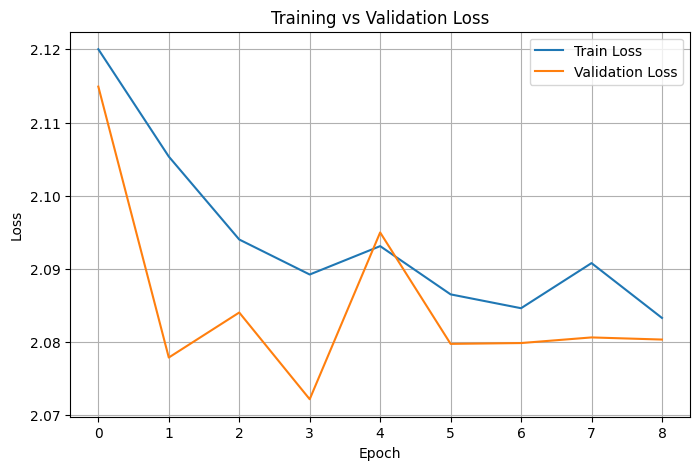

In [ ]:
print('=' * 50)
print('SECTION 8: TRAINING AND VALIDATION LOSS CURVES')
print('=' * 50)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.legend()
plt.show()

SECTION 8: TRAINING AND VALIDATION ACCURACY CURVES


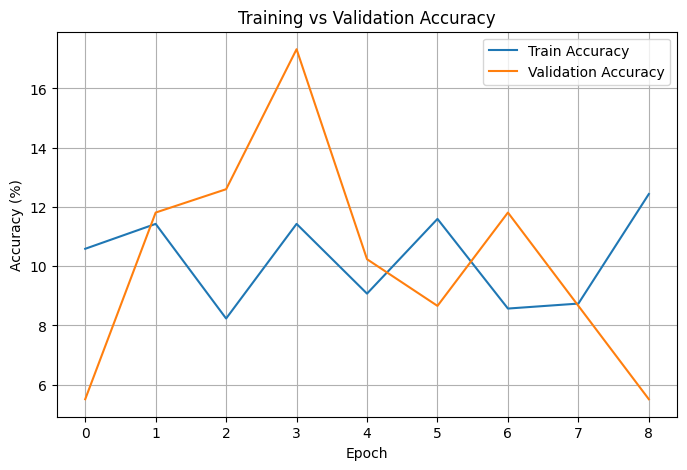

In [ ]:
print('=' * 50)
print('SECTION 8: TRAINING AND VALIDATION ACCURACY CURVES')
print('=' * 50)

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print('=' * 50)
print('SECTION 8: VALIDATION REPORT')
print('=' * 50)

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

val_true = []
val_pred = []

with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        predictions = outputs.argmax(dim=1)

        val_true.extend(labels.cpu().numpy())
        val_pred.extend(predictions.cpu().numpy())

target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(classification_report(val_true, val_pred, target_names=target_names, zero_division=0))

SECTION 8: VALIDATION REPORT
                  precision    recall  f1-score   support

           AK-12       0.17      1.00      0.30        22
           AK-47       0.00      0.00      0.00        13
IMI Desert Eagle       0.00      0.00      0.00        16
        M-Family       0.00      0.00      0.00        30
            M249       0.00      0.00      0.00        11
           MG-42       0.00      0.00      0.00        15
             MP5       0.00      0.00      0.00        13
     Zastava M92       0.00      0.00      0.00         7

        accuracy                           0.17       127
       macro avg       0.02      0.12      0.04       127
    weighted avg       0.03      0.17      0.05       127



In [ ]:
print('=' * 50)
print('SECTION 8: TEST REPORT')
print('=' * 50)

test_true = []
test_pred = []
test_correct = 0
test_total = 0

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        predictions = outputs.argmax(dim=1)

        test_true.extend(labels.cpu().numpy())
        test_pred.extend(predictions.cpu().numpy())
        test_total += labels.size(0)
        test_correct += (predictions == labels).sum().item()

final_test_accuracy = 100.0 * test_correct / test_total

print(classification_report(test_true, test_pred, target_names=target_names, zero_division=0))
print('=' * 50)
print(f'FINAL TEST ACCURACY: {final_test_accuracy:.2f}%')
print('=' * 50)

SECTION 8: TEST REPORT
                  precision    recall  f1-score   support

           AK-12       0.15      1.00      0.26        19
           AK-47       0.00      0.00      0.00        10
IMI Desert Eagle       0.00      0.00      0.00        13
        M-Family       0.00      0.00      0.00        28
            M249       0.00      0.00      0.00        18
           MG-42       0.00      0.00      0.00        14
             MP5       0.00      0.00      0.00        17
     Zastava M92       0.00      0.00      0.00        10

        accuracy                           0.15       129
       macro avg       0.02      0.12      0.03       129
    weighted avg       0.02      0.15      0.04       129

FINAL TEST ACCURACY: 14.73%


SECTION 8: CONFUSION MATRIX


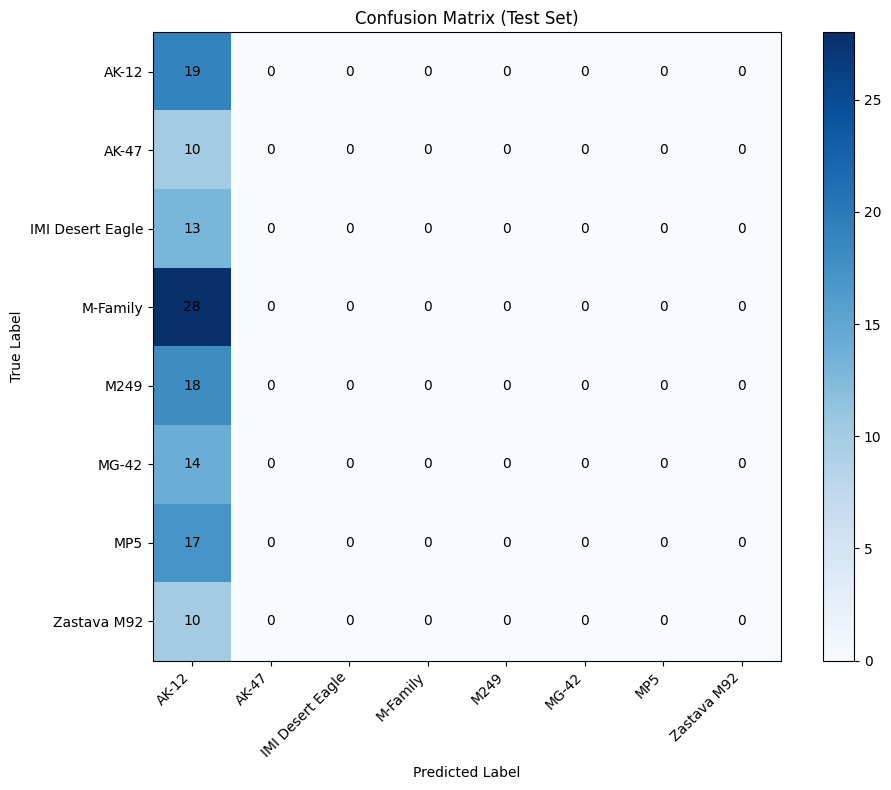

In [ ]:
print('=' * 50)
print('SECTION 8: CONFUSION MATRIX')
print('=' * 50)

cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, ha='right')
plt.yticks(tick_marks, target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='black')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import torch.nn.functional as F
import torchaudio.transforms as T
import soundfile as sf
import numpy as np

# ── LOAD FULL MODEL ───────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load("gunshot_pipeline.pkl", map_location=device, weights_only=False)
model.eval()

# ── CONFIG ────────────────────────────────────────────────────
SAMPLE_RATE    = 48000
TARGET_SEC     = 2
CONF_THRESHOLD = 40.0

idx_to_class = {
    0: "AK-12",        1: "AK-47",    2: "IMI Desert Eagle",
    3: "M-Family",     4: "M249",     5: "MG-42",
    6: "MP5",          7: "Zastava M92"
}

mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=40,
    melkwargs={"n_fft": 1024, "hop_length": 512, "n_mels": 64}
).to(device)

# ── INFERENCE FUNCTION ────────────────────────────────────────
def predict(file_path):
    # Load audio with soundfile — no FFmpeg needed
    data, sr = sf.read(file_path, always_2d=True)
    waveform = torch.tensor(data.T, dtype=torch.float32)  # [channels, samples]

    # Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # Resample to 48kHz if needed
    if sr != SAMPLE_RATE:
        resampler = T.Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
        waveform = resampler(waveform)

    # Pad / crop to 2s
    target = SAMPLE_RATE * TARGET_SEC
    if waveform.shape[1] > target:
        waveform = waveform[:, :target]
    else:
        waveform = F.pad(waveform, (0, target - waveform.shape[1]))

    # Pre-emphasis
    waveform = torch.cat((waveform[:, 0:1], waveform[:, 1:] - 0.97 * waveform[:, :-1]), dim=1)

    # Normalize
    waveform = waveform / (waveform.abs().max() + 1e-8)

    # MFCC + inference
    mfcc = mfcc_transform(waveform).unsqueeze(0).to(device)
    with torch.no_grad():
        conf, idx = torch.max(F.softmax(model(mfcc), dim=1), 1)

    confidence = conf.item() * 100
    prediction = idx_to_class[idx.item()] if confidence >= CONF_THRESHOLD else "Unknown Sound"
    return prediction, confidence

# ── RUN ───────────────────────────────────────────────────────
print('=' * 50)
print('GUNSHOT CLASSIFICATION — INFERENCE')
print('=' * 50)

file_path = input("Enter full path to .wav file: ").strip()

if os.path.exists(file_path):
    prediction, confidence = predict(file_path)
    print(f'\nFile       : {os.path.basename(file_path)}')
    print(f'Prediction : {prediction}')
    print(f'Confidence : {confidence:.2f}%')
else:
    print("File not found. Check the path and try again.")

GUNSHOT CLASSIFICATION — INFERENCE

File       : 3 (13).wav
Prediction : Unknown Sound
Confidence : 13.96%


In [ ]:
import os
from pathlib import Path

features_root = Path('features')
print(f"Features folder exists: {features_root.exists()}")

if features_root.exists():
    total = 0
    for cls in features_root.iterdir():
        if cls.is_dir():
            count = len(list(cls.glob('*.pt')))
            total += count
            print(f"  {cls.name}: {count} files")
    print(f"Total feature files: {total}")
else:
    print("Features folder does not exist!")

Features folder exists: True
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files
Total feature files: 851


In [ ]:
from pathlib import Path

features_root = Path('features')
class_to_idx = {
    "AK-12": 0, "AK-47": 1, "IMI Desert Eagle": 2,
    "M16": 3, "M4": 3,  # merged
    "M249": 4, "MG-42": 5, "MP5": 6, "Zastava M92": 7
}

found = [d.name for d in features_root.iterdir() if d.is_dir()]
print("Folders found:", found)
print("\nMapped correctly?")
for f in found:
    if f in class_to_idx:
        print(f"  {f} → label {class_to_idx[f]} ✅")
    else:
        print(f"  {f} → NOT IN MAPPING ❌")

Folders found: ['AK-12', 'AK-47', 'IMI Desert Eagle', 'M16', 'M249', 'M4', 'MG-42', 'MP5', 'Zastava M92']

Mapped correctly?
  AK-12 → label 0 ✅
  AK-47 → label 1 ✅
  IMI Desert Eagle → label 2 ✅
  M16 → label 3 ✅
  M249 → label 4 ✅
  M4 → label 3 ✅
  MG-42 → label 5 ✅
  MP5 → label 6 ✅
  Zastava M92 → label 7 ✅


In [ ]:
from pathlib import Path
import torch

features_root = Path('features')
class_to_idx = {
    "AK-12": 0, "AK-47": 1, "IMI Desert Eagle": 2,
    "M16": 3, "M4": 3,
    "M249": 4, "MG-42": 5, "MP5": 6, "Zastava M92": 7
}

samples = []
for cls_dir in features_root.iterdir():
    if cls_dir.is_dir() and cls_dir.name in class_to_idx:
        label = class_to_idx[cls_dir.name]
        for pt_file in cls_dir.glob('*.pt'):
            samples.append((pt_file, label))

print(f"Total samples loaded: {len(samples)}")

# Check first 5
for path, label in samples[:5]:
    tensor = torch.load(path, weights_only=True)
    print(f"  {path.parent.name}/{path.name} → label {label} | shape {tensor.shape}")

Total samples loaded: 851
  AK-12/3 (1).pt → label 0 | shape torch.Size([1, 40, 188])
  AK-12/3 (10).pt → label 0 | shape torch.Size([1, 40, 188])
  AK-12/3 (11).pt → label 0 | shape torch.Size([1, 40, 188])
  AK-12/3 (12).pt → label 0 | shape torch.Size([1, 40, 188])
  AK-12/3 (13).pt → label 0 | shape torch.Size([1, 40, 188])
